### CWODMR Notebook

##### In this experiment we will use the Pulseblaster, AOM, RF Switch and the Windfreak
##### The pulseblaster outputs should be connected as listed below:
###### 1. Output 0: Connect to AOM
###### 2. Output 1: Connect to Lock-in AMP REF IN input
###### 3. Output 23: Connect to the RF Switch TTL input

In [1]:
from Ametek_5210 import Ametek5210
from pulseblaster_d import pulseblasterd
from windfreak import windfreak

In [2]:
import numpy as np
import time
import datetime
import matplotlib.pyplot as plt
import csv

In [3]:
#initalize equiptment
pulser = pulseblasterd('pb')
rf = windfreak('windfreak', 'COM5')
lockin = Ametek5210('lockin', 'GPIB0::12::INSTR')

In [4]:
# This function determines the delay based on the tc of the lock in amp
def set_delay(lockin_tc):
    timeconst = {0: '1 ms',
    1: '3 ms',
    2: '10 ms',
    3: '30 ms' ,
    4: '100 ms',
    5: '300 ms',
    6: '1 s',
    7: '3 s',
    8: '10 s',
    9: '30 s',
    10: '100 s',
    11: '300 s',
    12: '1 ks',
    13: '3 ks'}

    timeconst_bw = {'1 ms' :0,
    '3 ms': 1,
    '10 ms': 2,
    '30 ms': 3 ,
    '100 ms': 4,
    '300 ms' : 5,
    '1 s' : 6,
    '3 s' : 7,
    '10 s': 8,
    '30 s': 9,
    '100 s': 10,
    '300 s': 11,
    '1 ks' : 12,
    '3 ks' : 13}

    tc_s = {0: 0.001,  #get timeconstant in secs
    1: 0.003,
    2: 0.01,
    3: 0.03 ,
    4: 0.1,
    5: 0.3,
    6: 1,
    7: 3,
    8: 10,
    9: 30,
    10: 100,
    11: 300,
    12: 1000,
    13: 3000}

    val = timeconst_bw[lockin_tc]
    if(type(val) != int):
        return "Error: invalid input!"
    else:
        return 5* tc_s[val]
    

#### The CWODMR experiemnt is setup below:
#### 1. Make sure all the equipment is turned on
#### 2. There are some parameters in the beginning you can set to see how the results change based on the values you set

##### If you run into any issues please let the TA know!

In [ ]:
def do_thing(power):
    #TODO: set below paramters
    rf_power = power #in dBm, do not exceed -10dBm (try -40 to -10 dBm)
    rf_step = 2 #MHz
    rf_start_freq = 2800  #feel free to adjust the range to see all the peaks (at 0 magnetic field, center of peaks are at 2870 MHz)
    rf_stop_freq = 3000 #MHz 

    #setup pulser:
    pulser._set_lock_in_width(2.5e-3)
    pulser.program_CWstate()
    pulser.start()

    rf_freqs = np.arange(rf_start_freq, rf_stop_freq, rf_step)
    #setup windfreak
    rf.set_channel(0)
    rf.set_power_dBm(rf_power)
    #turn on windfreak
    rf.on()

    #create array of outputs from the lockin amp
    vals = np.zeros(len(rf_freqs))
    #set your time constant. At each point you will wait 5x this time constant
    tc = '300 ms'

    #set the sensitivity and the time constant of the lock in amp
    lockin.sensitivity('30 mV') #30mV - you can use the smallest value that does not cause an overload error
    time.sleep(1)
    lockin.time_constant(tc) 
    #it is a good idea to confirm that these were set visually by looking at the amplifier display

    #set the delay based on the lockin time constant
    delay = set_delay(tc)

    for i in range(len(rf_freqs)):
        rf.set_freq(rf_freqs[i])
        time.sleep(int(delay)) #set using the time constant of the lockin amp later (5*timeconstant)
        val = lockin.magnitude()
        vals[i] = val
        print(val)

    pulser.stop() #turn off the output signals
    rf.off()

    plt.plot(rf_freqs, vals)
    plt.show()

Running for power -40
49.0
14.0
12.0
10.0
33.0
79.0
142.0
174.0
158.0
105.0
51.0
21.0
7.0
8.0
10.0
13.0
30.0
87.0
143.0
195.0
193.0
141.0
74.0
28.0
13.0
11.0
9.0
15.0
33.0
65.0
76.0
74.0
76.0
22.0
9.0
12.0
15.0
14.0
13.0
13.0
6.0
12.0
19.0
49.0
79.0
85.0
65.0
36.0
17.0
4.0
11.0
17.0
38.0
86.0
137.0
160.0
137.0
79.0
40.0
13.0
12.0
13.0
8.0
16.0
49.0
81.0
100.0
88.0
53.0
24.0
12.0
4.0
15.0
34.0
76.0
116.0
136.0
115.0
71.0
36.0
13.0
5.0
13.0
13.0
14.0
11.0
14.0
14.0
13.0
12.0
13.0
14.0
15.0
10.0
14.0
12.0
14.0
13.0
36.0
19.0


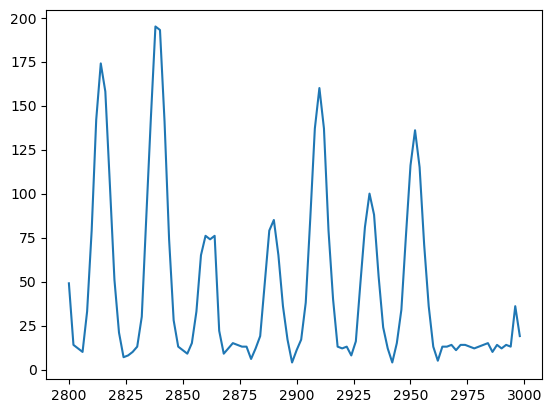

Running for power -30
51.0
35.0
28.0
48.0
112.0
216.0
341.0
390.0
363.0
269.0
154.0
64.0
24.0
9.0
12.0
37.0
97.0
205.0
323.0
405.0
405.0
320.0
199.0
97.0
42.0
22.0
31.0
66.0
128.0
208.0
250.0
235.0
168.0
87.0
33.0
12.0
14.0
14.0
8.0
7.0
5.0
28.0
86.0
167.0
239.0
252.0
206.0
124.0
66.0
32.0
29.0
50.0
123.0
229.0
316.0
355.0
317.0
214.0
113.0
49.0
20.0
17.0
28.0
69.0
149.0
225.0
263.0
241.0
161.0
87.0
45.0
35.0
49.0
101.0
201.0
288.0
323.0
278.0
190.0
100.0
44.0
14.0
13.0
9.0
14.0
15.0
17.0
12.0
14.0
9.0
10.0
12.0
14.0
13.0
8.0
15.0
13.0
13.0
13.0
13.0


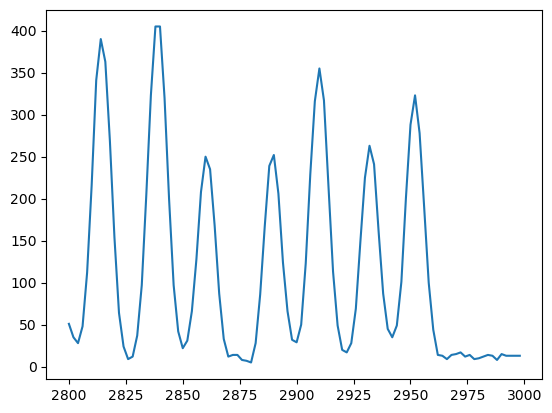

Running for power -20
147.0
132.0
116.0
172.0
294.0
444.0
572.0
627.0
601.0
495.0
338.0
185.0
98.0
65.0
76.0
132.0
241.0
398.0
522.0
604.0
596.0
521.0
390.0
238.0
133.0
98.0
128.0
220.0
366.0
498.0
555.0
533.0
428.0
265.0
125.0
44.0
15.0
27.0
32.0
16.0
49.0
128.0
268.0
430.0
537.0
559.0
503.0
365.0
218.0
131.0
122.0
181.0
307.0
455.0
565.0
597.0
551.0
432.0
277.0
152.0
86.0
79.0
125.0
236.0
383.0
504.0
568.0
536.0
425.0
281.0
166.0
128.0
172.0
283.0
424.0
543.0
581.0
541.0
417.0
267.0
136.0
54.0
13.0
16.0
26.0
35.0
26.0
24.0
25.0
26.0
28.0
26.0
26.0
25.0
27.0
24.0
24.0
24.0
23.0
21.0


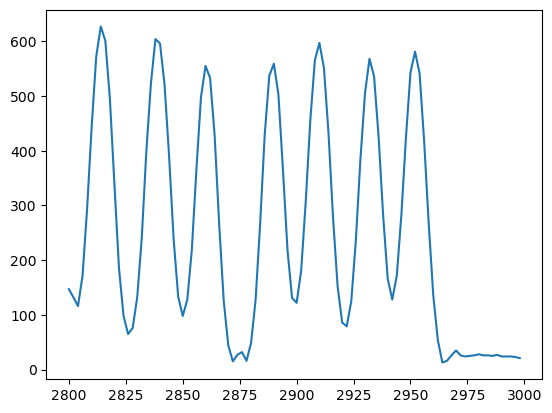

Running for power -10
446.0
531.0
560.0
643.0
755.0
884.0
979.0
1025.0
1000.0
901.0
750.0
589.0
470.0
421.0
427.0
502.0
612.0
730.0
826.0
871.0
849.0
779.0
673.0
548.0
437.0
401.0
439.0
559.0
691.0
795.0
837.0
801.0
692.0
530.0
353.0
224.0
152.0
120.0
127.0
166.0
252.0
396.0
567.0
714.0
804.0
831.0
776.0
661.0
528.0
430.0
421.0
492.0
603.0
710.0
786.0
807.0
770.0
670.0
545.0
428.0
361.0
363.0
437.0
575.0
718.0
821.0
858.0
820.0
718.0
582.0
455.0
406.0
438.0
532.0
625.0
699.0
718.0
681.0
577.0
431.0
272.0
150.0
76.0
31.0
26.0
33.0
40.0
35.0
46.0
50.0
55.0
52.0
67.0
68.0
73.0
77.0
78.0
73.0
64.0
61.0


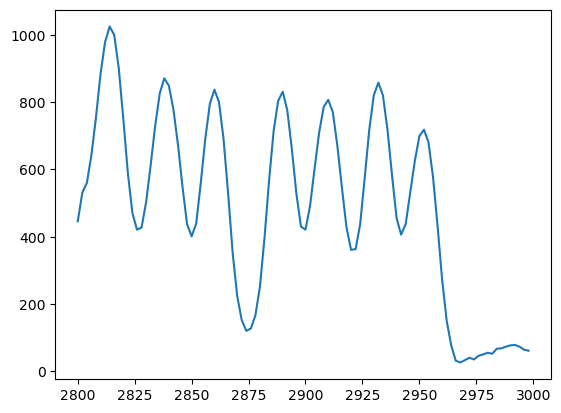

In [15]:
for power in range(-40, -0, 10):
    print(f'Running for power {power}')
    do_thing(power)

In [ ]:
do_thing(-10)

24.0
14.0
7.0
10.0
36.0
84.0
142.0
173.0


KeyboardInterrupt: 

In [ ]:
#write data to a csv file to save the data

dt = str(datetime.datetime.now()).strip().replace(' ', '-').replace('.','-').replace(':',"-")
filename = "cwodmr" + dt + ".csv"
header = ['rf_frequency(MHz)', 'Lock in amp mag']
with open(filename, 'w',newline='') as csvfile:
    csvwriter = csv.writer(csvfile)
    csvwriter.writerow(header)
    for i in range(len(vals)):
        row = [rf_freqs[i], vals[i]]
        csvwriter.writerow(row)
